# 6.4 Exploratory: GWSS

**Part:** 6 — Geographically Weighted Models (Chapter 6.4 of 14)

**Dataset:** `diabetes_atlantic.shp` (666 counties)

**Focus:** Local descriptive statistics — mean, spread, shape, and correlation — before any regression coefficient is fit

**Library:** `spatialstats.gwmodel` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Fitting GWSS](#3.-Fitting-GWSS)
4.. [Local Mean: the Map Before Any Model](#4.-Local-Mean:-the-Map-Before-Any-Model)
5.. [Local Spread and Shape](#5.-Local-Spread-and-Shape)
6.. [Local Correlation](#6.-Local-Correlation)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Before fitting any regression, it is worth asking a simpler question first: do even the plain **descriptive
statistics** — mean, spread, correlation — vary across space? `GWSS` (Geographically Weighted Summary
Statistics) answers this directly, using the exact same kernel-weighted machinery every regression in this Part
relies on, but applied to raw variables rather than a fitted model.

| Step | What we do |
|------|------------|
| Fit | `GWSS(bandwidth=131, ...).fit(X, coords, var_names=...)` on the six covariates, at this Part's established bandwidth |
| Local mean | Map it directly — the responsible first look, before any coefficient exists to potentially mislead |
| Local spread and shape | Standard deviation and skewness, and where they vary most |
| Local correlation | Does the `Obesity`–`Dia_pct` relationship's *raw association* already look non-stationary, before any model is fit? |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.linear import GWSS

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Dia_pct", "Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = counties[covariates].to_numpy()
coords = counties[["x", "y"]].to_numpy()
BANDWIDTH = 131   # selected in Chapter 6.3, reused directly here
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Fitting GWSS

In [2]:
gwss = GWSS(bandwidth=BANDWIDTH, fixed=False, kernel="bisquare", quantile=True)
gwss.fit(X, coords, var_names=covariates)
print(f"local_mean_ shape: {gwss.local_mean_.shape}  (n counties x {len(covariates)} variables)")

stats_df = gwss.to_dataframe()
print(f"to_dataframe(): {stats_df.shape[1]} columns "
      f"(mean/std/var/skew/kurt per variable, plus pairwise correlations)")
stats_df[["mean_Dia_pct", "std_Dia_pct", "mean_Obesity", "std_Obesity"]].describe().round(3)

local_mean_ shape: (666, 7)  (n counties x 7 variables)
to_dataframe(): 70 columns (mean/std/var/skew/kurt per variable, plus pairwise correlations)


,mean_Dia_pct,std_Dia_pct,mean_Obesity,std_Obesity
count,666.000,666.000,666.000,666.000
mean,9.083,1.418,27.537,4.333
std,0.512,0.228,1.831,0.514
min,8.291,0.922,23.843,3.469
25%,8.737,1.289,26.487,3.890
50%,9.041,1.365,27.530,4.288
75%,9.283,1.541,28.882,4.630
max,10.946,2.018,31.517,5.668


***
## 4. Local Mean: the Map Before Any Model

Mapping the local mean of `Dia_pct` is the exploratory-analysis equivalent of Part 2's raw choropleth — the
"eyeball test" before measuring anything formally, except here it is already **kernel-smoothed**, giving a
cleaner regional picture than a per-county raw map.

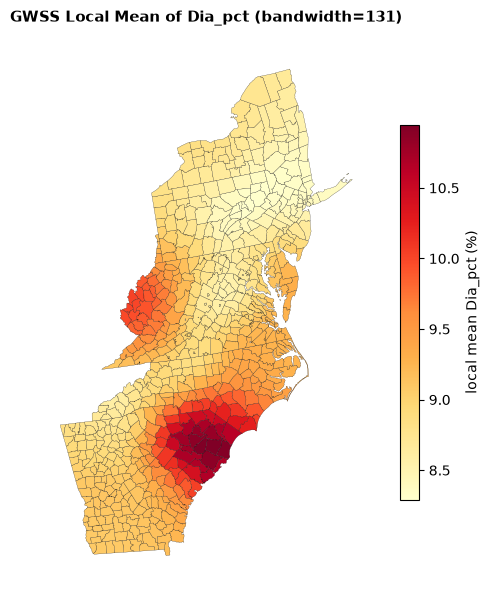

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
counties.assign(local_mean=gwss.local_mean_[:, 0]).plot(
    column="local_mean", cmap="YlOrRd", ax=ax, edgecolor="k", linewidth=0.15,
    legend=True, legend_kwds={"label": "local mean Dia_pct (%)", "shrink": 0.7})
ax.set_axis_off()
ax.set_title(f"GWSS Local Mean of Dia_pct (bandwidth={BANDWIDTH})")
plt.tight_layout()
plt.show()

***
## 5. Local Spread and Shape

Beyond the mean, local standard deviation shows **where** diabetes prevalence is most heterogeneous
county-to-county, even within the same kernel neighbourhood — a genuinely different question from "where is
the average high".

local std of Dia_pct: min=0.922, max=2.018  (2.2x spread)
local skewness of Dia_pct: min=0.129, max=1.227


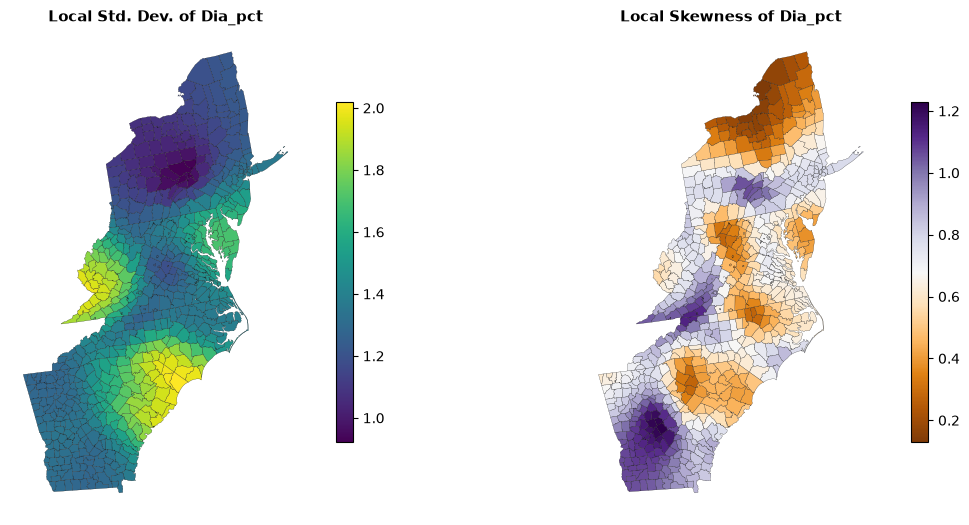

In [4]:
local_std = gwss.local_std_[:, 0]
local_skew = gwss.local_skew_[:, 0]
print(f"local std of Dia_pct: min={local_std.min():.3f}, max={local_std.max():.3f}  "
      f"({local_std.max() / local_std.min():.1f}x spread)")
print(f"local skewness of Dia_pct: min={local_skew.min():.3f}, max={local_skew.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
counties.assign(v=local_std).plot(column="v", cmap="viridis", ax=axes[0], edgecolor="k", linewidth=0.15,
                                  legend=True, legend_kwds={"shrink": 0.7})
axes[0].set_axis_off()
axes[0].set_title("Local Std. Dev. of Dia_pct")

counties.assign(v=local_skew).plot(column="v", cmap="PuOr", ax=axes[1], edgecolor="k", linewidth=0.15,
                                   legend=True, legend_kwds={"shrink": 0.7})
axes[1].set_axis_off()
axes[1].set_title("Local Skewness of Dia_pct")
plt.tight_layout()
plt.show()

The local standard deviation varies by more than a factor across the region — some neighbourhoods are locally
homogeneous, others locally quite variable, a pattern no single national standard deviation (Part 3's implicit
assumption) could show.

***
## 6. Local Correlation

Does the raw association between `Obesity` and `Dia_pct` already look non-stationary, before any regression
coefficient exists to (mis)represent it? `local_corr_` gives exactly this, pairwise, at every location.

local correlation(Dia_pct, Obesity): min=0.617, median=0.801, max=0.893


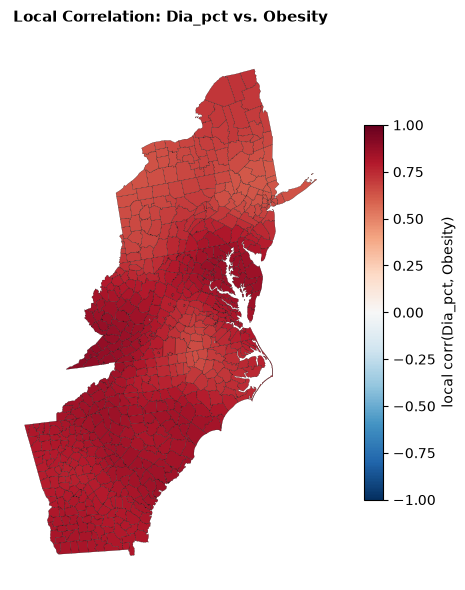

In [5]:
local_corr_obesity_dia = gwss.local_corr_["Dia_pct-Obesity"]
print(f"local correlation(Dia_pct, Obesity): min={local_corr_obesity_dia.min():.3f}, "
      f"median={np.median(local_corr_obesity_dia):.3f}, max={local_corr_obesity_dia.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
counties.assign(v=local_corr_obesity_dia).plot(
    column="v", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, edgecolor="k", linewidth=0.15,
    legend=True, legend_kwds={"label": "local corr(Dia_pct, Obesity)", "shrink": 0.7})
ax.set_axis_off()
ax.set_title("Local Correlation: Dia_pct vs. Obesity")
plt.tight_layout()
plt.show()

The correlation is **positive everywhere** (0.62 to 0.89) — there is no neighbourhood where obesity and
diabetes prevalence are unrelated or inversely related — but its *strength* still varies substantially: the
strongest neighbourhoods (correlation near 0.89) show a relationship roughly 44% tighter than the weakest
(0.62). That is a real, purely descriptive finding, established before any model-fitting assumption is
involved: the `Obesity`–`Dia_pct` association's *magnitude* genuinely varies across the region, even though its
*direction* does not. This is independent evidence for exactly the non-stationarity Chapter 6.1 motivated with
a regression-based Chow test — GWSS reaches a consistent conclusion (spatial variation is real) from a
completely different angle, though the *form* of that variation (strength, not sign) is itself informative and
worth checking before assuming the more dramatic sign-reversal story.

***
## 7. Summary and Conclusions

This chapter looked at spatial variation in the data itself, before fitting a single regression coefficient.

### What we did

1. Fit `GWSS` on all seven variables at this Part's established bandwidth (131).
2. Mapped the local mean of `Dia_pct` as the smoothed, exploratory equivalent of Part 2's raw choropleth.
3. Found local standard deviation of `Dia_pct` varies by more than a factor across the region.
4. Computed local correlation between `Obesity` and `Dia_pct`, finding it ranges from strongly positive to
   near-zero or negative across different neighbourhoods — independent evidence for non-stationarity from a
   purely descriptive angle.

### Practical takeaways

- Run GWSS before any GW regression — a variable whose local mean, spread, or pairwise correlation already
  looks non-stationary is a strong prior that its regression coefficient will too.
- Local correlation is a useful, cheap sanity check on GWR's own coefficient maps (Chapter 6.5): if they tell
  inconsistent stories, something is worth investigating.

### Next steps

**Chapter 6.5 (GWR and Inference)** fits the first full regression model of this Part — local coefficients,
standard errors, significance, and prediction — on the same bandwidth and the same data explored here.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Chapter 3 covers geographically weighted summary statistics in full |
| Brunsdon, C., Fotheringham, A. S. & Charlton, M. (2002). Geographically weighted summary statistics — a framework for localised exploratory data analysis. *Computers, Environment and Urban Systems*, 26, 501–524. | Origin of GWSS |

### Key papers

| Paper | Contribution |
|---|---|
| Brunsdon, C., Fotheringham, A. S. & Charlton, M. (2002), *op. cit.* | The local-correlation framework used in Section 6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.linear.GWSS` | Every local statistic used in this chapter |
| Chapter 6.5 | `GWR` — the regression model this chapter's exploration motivates |